In [1]:
import open3d as o3d
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

# Only needed for tutorial
sys.path.append('..')

import open3d.examples as o3dtut
# Change to True if you want to interact with the visualization windows
o3dtut.interactive = not 'CI' in os.environ

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


##  RGBD Images
- Open3D has a data structure for images. It supports various functions such as read_image, write_image, filter_image and draw_geometries. An Open3D Image can be directly converted to/from a numpy array.

## 1. Redwood Dataset

In [10]:
print("Read Redwood dataset")
redwood_rgbd = o3d.data.SampleRedwoodRGBDImages()
color_raw = o3d.io.read_image(redwood_rgbd.color_paths[0])
depth_raw = o3d.io.read_image(redwood_rgbd.depth_paths[0])
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_raw)
print(rgbd_image)

Read Redwood dataset
RGBDImage of size 
Color image : 640x480, with 1 channels.
Depth image : 640x480, with 1 channels.
Use numpy.asarray to access buffer data.


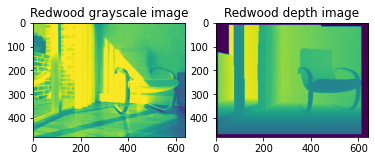

In [11]:
plt.subplot(1, 2, 1)
plt.title('Redwood grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Redwood depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [12]:
print(np.asarray(color_raw).shape)
print(np.asarray(depth_raw).shape)

(480, 640, 3)
(480, 640)


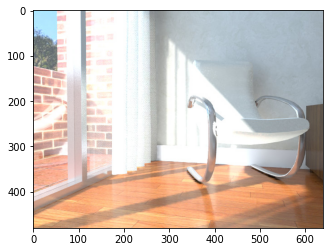

In [13]:
plt.imshow(np.asarray(color_raw))

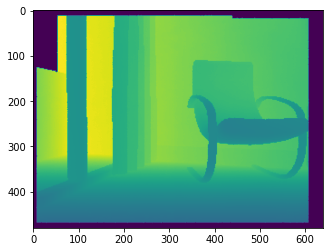

In [14]:
plt.imshow(np.asarray(depth_raw))

## Creating pointCloud from RGBD Images

- Here we use PinholeCameraIntrinsicParameters.PrimeSenseDefault as default camera parameter. It has image resolution 640x480, focal length (fx, fy) = (525.0, 525.0), and optical center (cx, cy) = (319.5, 239.5). An identity matrix is used as the default extrinsic parameter. pcd.transform applies an up-down flip transformation on the point cloud for better visualization purpose.

In [20]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


## 2. SUN Dataset

- The only difference is that we use the conversion function `create_rgbd_image_from_sun_format` to parse depth images in the SUN dataset.

In [21]:
print("Read SUN dataset")
sun_rgbd = o3d.data.SampleSUNRGBDImage()
color_raw = o3d.io.read_image(sun_rgbd.color_path)
depth_raw = o3d.io.read_image(sun_rgbd.depth_path)
rgbd_image = o3d.geometry.RGBDImage.create_from_sun_format(color_raw, depth_raw)
print(rgbd_image)

Read SUN dataset
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/SampleSUNRGBDImage.zip
[Open3D INFO] Downloaded to C:\Users\vikas/open3d_data/download/SampleSUNRGBDImage/SampleSUNRGBDImage.zip
[Open3D INFO] Created directory C:\Users\vikas/open3d_data/extract/SampleSUNRGBDImage.
[Open3D INFO] Extracting C:\Users\vikas/open3d_data/download/SampleSUNRGBDImage/SampleSUNRGBDImage.zip.
[Open3D INFO] Extracted to C:\Users\vikas/open3d_data/extract/SampleSUNRGBDImage.
RGBDImage of size 
Color image : 640x480, with 1 channels.
Depth image : 640x480, with 1 channels.
Use numpy.asarray to access buffer data.


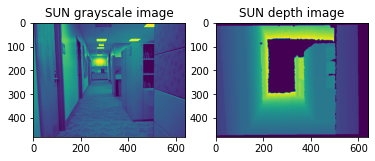

In [22]:
plt.subplot(1, 2, 1)
plt.title('SUN grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('SUN depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [25]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

## 3. NYU Dataset

- NYU images are not in standard jpg or png formats. Thus, we use mpimg.imread to read the color image as a numpy array and convert it to an Open3D Image. An additional helper function read_nyu_pgm is called to read depth images from the special big endian pgm format used in the NYU dataset.

- We use a different conversion function create_rgbd_image_from_nyu_format to parse depth images in the SUN dataset.

In [26]:
import matplotlib.image as mpimg
import re


# This is special function used for reading NYU pgm format
# as it is written in big endian byte order.
def read_nyu_pgm(filename, byteorder='>'):
    with open(filename, 'rb') as f:
        buffer = f.read()
    try:
        header, width, height, maxval = re.search(
            b"(^P5\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n]\s)*)", buffer).groups()
    except AttributeError:
        raise ValueError("Not a raw PGM file: '%s'" % filename)
    img = np.frombuffer(buffer,
                        dtype=byteorder + 'u2',
                        count=int(width) * int(height),
                        offset=len(header)).reshape((int(height), int(width)))
    img_out = img.astype('u2')
    return img_out


print("Read NYU dataset")
# Open3D does not support ppm/pgm file yet. Not using o3d.io.read_image here.
# MathplotImage having some ISSUE with NYU pgm file. Not using imread for pgm.
nyu_rgbd = o3d.data.SampleNYURGBDImage()
color_raw = mpimg.imread(nyu_rgbd.color_path)
depth_raw = read_nyu_pgm(nyu_rgbd.depth_path)
color = o3d.geometry.Image(color_raw)
depth = o3d.geometry.Image(depth_raw)
rgbd_image = o3d.geometry.RGBDImage.create_from_nyu_format(color, depth)
print(rgbd_image)

Read NYU dataset
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/SampleNYURGBDImage.zip
[Open3D INFO] Downloaded to C:\Users\vikas/open3d_data/download/SampleNYURGBDImage/SampleNYURGBDImage.zip
[Open3D INFO] Created directory C:\Users\vikas/open3d_data/extract/SampleNYURGBDImage.
[Open3D INFO] Extracting C:\Users\vikas/open3d_data/download/SampleNYURGBDImage/SampleNYURGBDImage.zip.
[Open3D INFO] Extracted to C:\Users\vikas/open3d_data/extract/SampleNYURGBDImage.
RGBDImage of size 
Color image : 640x480, with 1 channels.
Depth image : 640x480, with 1 channels.
Use numpy.asarray to access buffer data.


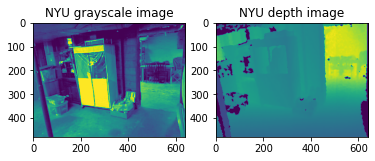

In [27]:
plt.subplot(1, 2, 1)
plt.title('NYU grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('NYU depth image')
plt.imshow(rgbd_image.depth)
plt.show()


In [29]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is no

## 4. TUM Dataset

In [37]:
print("Read TUM dataset")
tum_rgbd = o3d.data.SampleSUNRGBDImage()
color_raw = o3d.io.read_image(tum_rgbd.color_path)
depth_raw = o3d.io.read_image(tum_rgbd.depth_path)
rgbd_image = o3d.geometry.RGBDImage.create_from_tum_format(color_raw, depth_raw)
print(rgbd_image)

Read TUM dataset
RGBDImage of size 
Color image : 640x480, with 1 channels.
Depth image : 640x480, with 1 channels.
Use numpy.asarray to access buffer data.


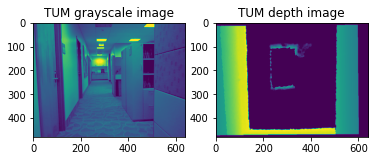

In [38]:
plt.subplot(1, 2, 1)
plt.title('TUM grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('TUM depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [39]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])